In [ ]:
from IPython.display import display

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
import pathlib
from pathlib import Path
from scipy.stats import chi2_contingency

# sklearn
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler


# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense,Input,BatchNormalization,Dropout
# from tensorflow.keras.optimizers import Adam

# # Importing XGboost algorithm
import xgboost as xgb


# Kaggle start up code
import os
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [22]:
class Sampler:
    '''
    This class handles sampling.
    '''
    def load(self, df, target_column):
        self.df = df
        self.target_column = target_column
        
    def compute_weights(self, label_series: pd.Series)->pd.Series:
        '''
        This method is used internally to compute weights for sampling.
        '''
        label_count = label_series.value_counts()
        label_count = label_count.values / sum(label_count)
        noise = np.random.randint(1, 5)
        print(f'Random noise added: {noise}')
        label_count *= -1 * noise
        label_count = np.round(tf.nn.softmax(label_count),2)
        label_series = label_series.apply(lambda x: label_count[x])
        return label_series

    def random_sampling(self, n_samples:int, weighted: bool = False)->list[np.ndarray]:
        '''
        Plain random sampling
        '''
        weights = None
        if weighted:
            weights = self.compute_weights(self.df[self.target_column])
        df = self.df.sample(n=n_samples, replace=False, weights = weights)
        return df.iloc[:, :-1], df.iloc[:, -1]
        
    def sampling_w_replacement(self, weighted: bool = False)->list[np.ndarray]:
        '''
        Sampling with replacement, same as random_sampling but the sampled instances are replaced.
        '''
        weights = None
        if weighted:
            weights = self.compute_weights(self.df[self.target_column])
        df = self.df.sample(frac = 1, replace = True, weights = weights)
        return df.iloc[:, :-1], df.iloc[:, -1]

    def stratified_eq_sampling(self, n_samples:int)->list[np.ndarray]:
        '''
        Stratified sampling to sample specified distribution. In our case we want 50% or equal percentage of class labels.
        '''
        if n_samples % 2 != 0:
            print('Adding one to make sample size even')
            n_samples += 1
        grouped_df = self.df.groupby(self.target_column, observed = False)
        stratified_df = grouped_df.apply(lambda x: x.sample(n = n_samples, replace = True), include_groups = False)
        stratified_df = stratified_df.droplevel(level = 1)
        stratified_df = stratified_df.reset_index()
        return stratified_df.iloc[:, 1:], stratified_df.iloc[:, 0]
        
    def smote(self, X, y, sampling:str = 'all', neighbors:int = 5)->list[np.ndarray]:
        '''
        Smote method. Uses imbalance-learn.
        '''
        smt = SMOTE(sampling_strategy = sampling, k_neighbors = neighbors)
        return smt.fit_resample(X, y)

In [23]:
class Preprocess:
    '''
    Class for parsing, pretty printing and preprocessing the dataset.
    All methods here calls the display method, to display result as a dataframe.
    '''
    
    def display(self, data: dict| pd.DataFrame):
        if type(data) == 'pandas.core.frame.DataFrame':
            display(data)
        else:
            display(pd.DataFrame(data = data))
        
    def column_dtypes(self, df: pd.DataFrame)->None:
        '''
        Method to display column names and its respective data types as a dataframe.
        '''
        columns = list(df.columns)
        dtypes = list(df.dtypes)
        self.display({'Columns': columns, 'Dtypes': dtypes})

    def category_unique_values(self, df: pd.DataFrame)->None:
        '''
        Method to display category column names and its number of unique values as a dataframe.
        '''
        unique_values_count = []
        features = []
        for column in df.columns:
            if df[column].dtype == 'object':
                features.append(column)
                unique_values_count.append(df[column].nunique())
        self.display({'Columns': features, 'Unique Values': unique_values_count})
        

    def as_dtype(self, df: pd.DataFrame, _from, _to)->pd.DataFrame:
        '''
        Method to convert a columns dtype from one type to another. Advantage is, it works on all the columns in the dataframe 
        having same dtype of focus
        '''
        for column in df.columns:
            if df[column].dtype == _from:
                df[column] = df[column].astype(_to)
        return df

    def has_nan(self, df: pd.DataFrame)->list[str]:
        '''
        Method to display column names and whether it contains null values as a dataframe.
        '''
        has_na = []
        na_present = []
        for index, column in enumerate(df.columns):
            decision = df[column].hasnans
            has_na.append(decision)
            if decision:
                na_present.append(column)
        self.display({'Columns': list(df.columns), 'has_NaN': has_na})
        return na_present
        
    def check_category_correlation(self, df:pd.DataFrame, variable:str, p_value:int)->list:
        '''
        Method used to compute correlation between category variables. Highlights feature dependancy.
        '''
        result = []
        for column in df.columns:
            if df[column].dtype in ['object', 'category'] and column != variable:
                contingency_table = pd.crosstab(df[column], df[variable])
                chi2, p, dof, expected = chi2_contingency(contingency_table)
                if p < p_value:
                    result.append((column, p, dof))
        return result

    def standardize(self,df:pd.DataFrame | np.ndarray)->pd.DataFrame:
        '''
        Method for standardizing the input. Uses StandardScaler from sklearn.
        '''
        norm = StandardScaler()
        return norm.fit_transform(df)

    def normalize(self,df:pd.DataFrame | np.ndarray)->pd.DataFrame:
        '''
        Method for normalizing the input. Uses MinMaxScaler from sklearn.
        '''
        norm = MinMaxScaler()
        return norm.fit_transform(df)
    
    def __onehot(self, df:pd.DataFrame)->pd.DataFrame:
        '''
        Method for one-hot encoding the input using pandas get_dummies.
        '''
        return pd.get_dummies(df, dtype=int)

    def __label(self, feature: pd.Series)->pd.Series:
        '''
        Method for label encoding the input. Uses LabelEncoded from sklearn.
        '''
        label_encoder = LabelEncoder()
        return label_encoder.fit_transform(feature) 

    def __label_all(self, df:pd.DataFrame)->pd.DataFrame:
        '''
        Method for label encode the whole DataFrame rathere than a single column. Uses LabelEncoded from sklearn.
        '''
        new_df = df.copy()
        for column in new_df.columns:
            if new_df[column].dtype in ['object', 'category']:
                new_df[column] = self.__label(new_df[column])
        return new_df
         
    def encode(self, df:pd.DataFrame, _type: str = 'Label')->pd.DataFrame:
        '''
        Factory method to invoke type of encoding based on _type value.
        '''
        match(_type):
            case 'OneHot': 
                target_column = df.columns[-1]
                new_df = self.__onehot(df.iloc[:, :-1])
                new_df[target_column] = self.__label(df.iloc[:-1])     
                return new_df
            case 'Label':
                return self.__label_all(df)
            case _: return 'Not Supported!!'

In [24]:
class Pipeline:
    '''
    Pipeline to run models.
    '''
    def __init__(self):
        self.models = {}

    def initialize(self, X:np.ndarray | pd.DataFrame, y: np.ndarray | pd.Series, normalizer, test_size:int = 0.3):
        '''
        Inititalize the pipeline with X and y along with normalizer and test_size
        '''        
        self.X = normalizer(X)
        self.y = y
        self.train_X, self.test_x, self.train_y, self.test_y = train_test_split(dt_X, dt_y, test_size = test_size)

    def load(self, model_name:str, model:any)->None:
        '''
        Load the model of choice.
        '''
        self.models[model_name] = model

    def unload(self, model_name:str)->None:
        '''
        Unload a model of choice.
        '''
        if model_name in self.models:
            del self.models[model_name]

    def reset(self):
        '''
        Reset the pipeline.
        '''
        self.models = {}

    def process(self)->None:
        '''
        This method is used to run all the models present to fit train data and predict test data.
        '''
        for model_name, model in self.models.items():
            model.fit(self.train_X, self.train_y)
            predictions = np.round(model.predict(self.test_x))
            predictions = (predictions >= 0.5).astype(int)
            self.report(model_name, predictions, self.test_y)

    def report(self, model_name:str,  y_pred:np.ndarray, y_actual:np.ndarray)->None:
        '''
        Used internally for reporting by process method.
        '''
        print(f'---------------{model_name}---------------')
        print(classification_report(y_pred, y_actual, zero_division = 0))
        print('\n\n')

In [25]:
class Visualize:
    '''
    Class for visualizing categorical variables(as of now)
    '''
    def __init__(self):
        self.colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink', 'cyan', 'teal']
    
    def __pie(self, feature: np.ndarray | pd.Series, colors:list[str], explode:bool)->None:
        '''
        Function to plot pie chart using plt.
        '''
        explosion = [0] * len(feature)
        if explode:
            explosion = [0.05  if x == 'nan' else 0 for x in feature.index]
        plt.pie(
            x=feature.values,
            labels=feature.index,
            autopct= '%1.1f%%',
            colors= colors,
            explode = explosion,
            wedgeprops={"alpha": 0.4}
        )

    
    def __bar(self,feature: np.ndarray | pd.Series, colors:list[str])->None:
        '''
        Function to plot pie chart using plt.
            
        '''
        plt.bar(x=feature.index, height = feature.values, color= colors , label = feature.index,  alpha= 0.5)
        plt.legend()
        plt.xticks(rotation=45)

    def __category(self, feature: np.ndarray | pd.Series, title: str, explode_na:bool=True)->None:
        '''
        Method to plot both pie and bar graphs. If the number of categories is large, then by default plots bar graph.
        '''
        target_labels_count = feature.value_counts(dropna=False).sort_values()
        target_labels_count_length = len(target_labels_count.values)
        # Convert all values into string to make sure NaN is included
        target_labels_count.index = target_labels_count.index.map(lambda x: str(x))
        colors = np.random.choice(self.colors, size=target_labels_count_length, replace=len(self.colors) <= target_labels_count_length)
        if len(self.colors) <= target_labels_count_length:
            plt.figure(figsize=(20, 8))
            plt.title(title)
            return self.__bar(target_labels_count, colors)
        plt.suptitle(title)
        plt.subplot(121)
        self.__pie(target_labels_count, colors, explode_na)
        plt.subplot(122)
        self.__bar(target_labels_count, colors)
        plt.tight_layout()
        plt.show()
    
    def feature(self, feature: np.ndarray | pd.Series, explode_na:bool=True)->None:
        '''
        Method that initites the plotting. Should be invoked in order to plot both bar graph and pie chart.
        '''
        title = f'{feature.name} <---> {feature.dtype}'.title()
        return self.__category(feature,title, explode_na)
        # if feature.dtype in ['object', 'category']:
        #     return self.__category(feature,title, explode_na)
        # else:
        #     return 'Not available for other data types'
        
        

In [26]:
vz = Visualize()
prep = Preprocess()
sampler = Sampler()
pipe = Pipeline()

In [27]:
PROJECT_ROOT = Path.cwd()  # if your notebook is inside data_science folder
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw_data.csv"

try:
    _df = pd.read_csv(RAW_DATA_PATH)
    print("Data Loaded Successfully!")
except FileNotFoundError:
    print(f"File not found at {RAW_DATA_PATH.resolve()}")

Data Loaded Successfully!


In [28]:
population_1 = _df[~_df['Mutation_Type'].isna() & ~_df['Treatment_Access'].isna()]
population_1

,Country,Age,Gender,Smoking_Status,Second_Hand_Smoke,Air_Pollution_Exposure,Occupation_Exposure,Rural_or_Urban,Socioeconomic_Status,Healthcare_Access,...,Treatment_Access,Clinical_Trial_Access,Language_Barrier,Mortality_Risk,5_Year_Survival_Probability,Delay_in_Diagnosis,Family_History,Indoor_Smoke_Exposure,Tobacco_Marketing_Exposure,Final_Prediction
0,Russia,82,Male,Former Smoker,Yes,Medium,No,Urban,High,Limited,...,Partial,Yes,No,0.263278,0.797576,Yes,No,No,No,No
1,Thailand,66,Female,Former Smoker,No,High,No,Rural,Middle,Good,...,Partial,Yes,No,0.154697,0.336674,Yes,No,No,Yes,No
2,Colombia,87,Male,Former Smoker,No,Medium,No,Urban,Low,Poor,...,Partial,Yes,No,0.607435,0.063621,No,No,No,Yes,No
3,Egypt,51,Female,Former Smoker,No,Low,Yes,Rural,High,Good,...,Full,No,No,0.081184,0.336814,No,No,No,Yes,No
6,USA,38,Male,Former Smoker,Yes,Medium,No,Urban,Middle,Poor,...,Partial,No,No,0.530530,0.653562,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460287,Russia,46,Female,Former Smoker,Yes,Medium,No,Urban,Middle,Poor,...,Partial,No,No,0.794849,0.521195,No,No,No,No,Yes
460288,Pakistan,63,Female,Non-Smoker,No,Low,No,Urban,Middle,Good,...,Partial,No,No,0.198008,0.907028,No,No,No,No,Yes
460289,Germany,51,Female,Smoker,No,Low,No,Urban,High,Poor,...,Partial,No,No,0.491532,0.866276,Yes,Yes,No,Yes,No
460290,Italy,83,Female,Former Smoker,No,Low,No,Urban,Middle,Good,...,Full,No,No,0.077730,0.610409,No,No,No,No,Yes


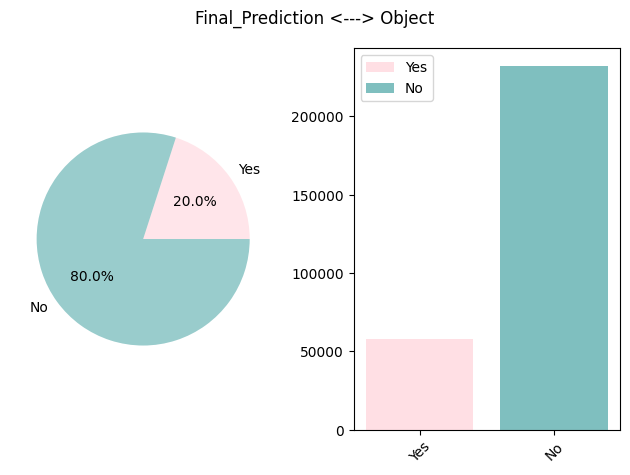

In [29]:
vz.feature(population_1['Final_Prediction'])

In [30]:
encoded = prep.encode(population_1)
sampler.load(encoded, 'Final_Prediction')

In [31]:
dt = DecisionTreeClassifier()
pipe.load('Decision Tree',dt)
rf = RandomForestClassifier(n_estimators=20, random_state=42, class_weight='balanced')
pipe.load('Random Forest',rf)
xg = xgb.XGBClassifier()
pipe.load('XG-Boost', xg)
# nn = Sequential([
#             Dense(128, activation='relu'),
#             Dense(64, activation='relu'),
#             Dense(1, activation='sigmoid')
#         ])
    
# nn.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
# pipe.load('Neural Networks', nn)

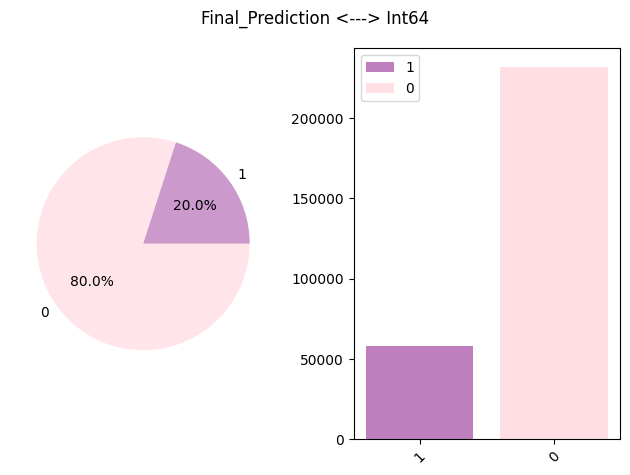

---------------Decision Tree---------------
              precision    recall  f1-score   support

           0       0.77      0.80      0.78     66749
           1       0.23      0.20      0.21     20226

    accuracy                           0.66     86975
   macro avg       0.50      0.50      0.50     86975
weighted avg       0.64      0.66      0.65     86975




---------------Random Forest---------------
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     86889
           1       0.00      0.21      0.00        86

    accuracy                           0.80     86975
   macro avg       0.50      0.51      0.45     86975
weighted avg       1.00      0.80      0.89     86975




---------------XG-Boost---------------
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     86915
           1       0.00      0.22      0.00        60

    accuracy                           0.80     8

In [32]:
dt_X, dt_y = sampler.random_sampling(population_1.shape[0])
pipe.initialize(dt_X, dt_y, prep.normalize, 0.3)
vz.feature(dt_y)
pipe.process()

In [33]:
prep.display({'Features': encoded.columns[:-1], 'Importance by Desicion tree': np.round(dt.feature_importances_,3) * 100, 'Importance by Random forest': np.round(rf.feature_importances_,3) * 100})

,Features,Importance by Desicion tree,Importance by Random forest
0,Country,10.9,11.3
1,Age,12.3,12.9
2,Gender,1.4,1.9
3,Smoking_Status,3.2,3.6
4,Second_Hand_Smoke,1.8,2.0
5,Air_Pollution_Exposure,2.9,3.4
6,Occupation_Exposure,1.5,1.7
7,Rural_or_Urban,1.5,1.8
8,Socioeconomic_Status,3.1,3.3
9,Healthcare_Access,2.7,3.2


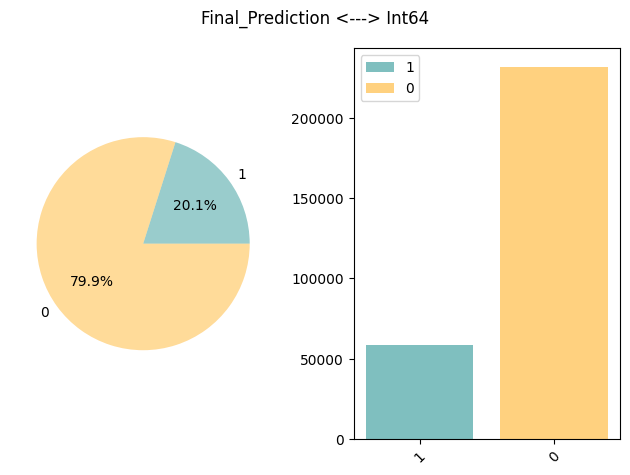

In [34]:
dt_X, dt_y = sampler.sampling_w_replacement(weighted=False)
vz.feature(dt_y)

Random noise added: 2


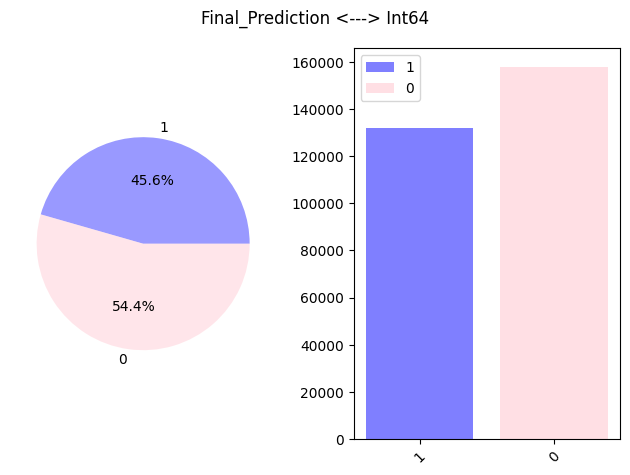

In [36]:
dt_X, dt_y = sampler.sampling_w_replacement(weighted=True)
vz.feature(dt_y)

Random noise added: 3


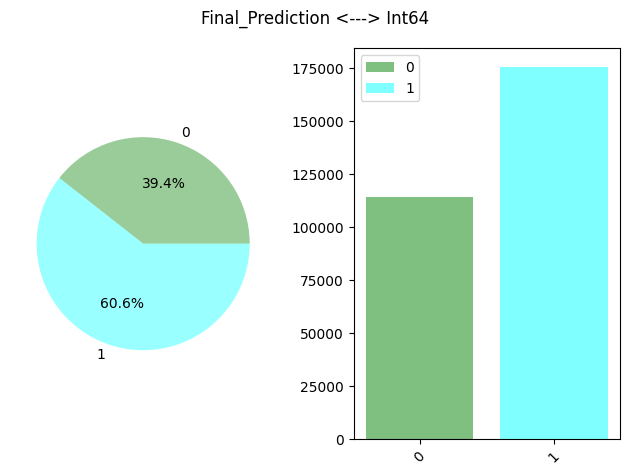

In [38]:
dt_X, dt_y = sampler.sampling_w_replacement(weighted=True)
vz.feature(dt_y)


Random noise added: 1


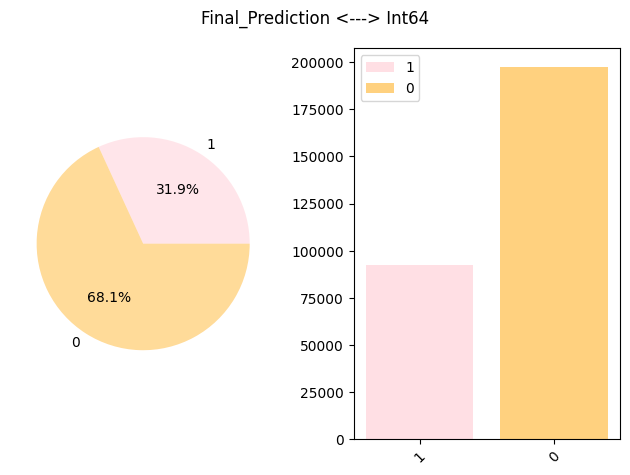

---------------Decision Tree---------------
              precision    recall  f1-score   support

           0       0.84      0.89      0.86     55941
           1       0.77      0.69      0.73     31034

    accuracy                           0.82     86975
   macro avg       0.80      0.79      0.80     86975
weighted avg       0.81      0.82      0.81     86975




---------------Random Forest---------------
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     67711
           1       0.67      0.97      0.79     19264

    accuracy                           0.89     86975
   macro avg       0.83      0.92      0.86     86975
weighted avg       0.92      0.89      0.89     86975




---------------XG-Boost---------------
              precision    recall  f1-score   support

           0       0.99      0.69      0.81     85110
           1       0.05      0.70      0.09      1865

    accuracy                           0.69     8

In [40]:
dt_X, dt_y = sampler.sampling_w_replacement(weighted=True)
pipe.initialize(dt_X, dt_y, prep.normalize, 0.3)
vz.feature(dt_y)
pipe.process()

Random noise added: 3


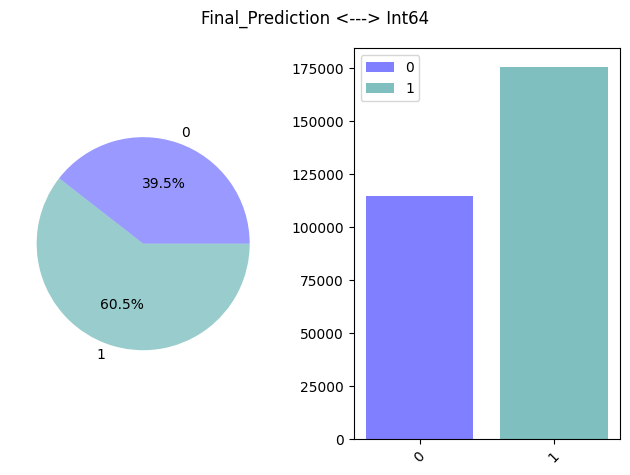

---------------Decision Tree---------------
              precision    recall  f1-score   support

           0       0.71      0.87      0.78     27987
           1       0.93      0.83      0.88     58988

    accuracy                           0.84     86975
   macro avg       0.82      0.85      0.83     86975
weighted avg       0.86      0.84      0.84     86975




---------------Random Forest---------------
              precision    recall  f1-score   support

           0       0.73      0.86      0.79     29225
           1       0.92      0.84      0.88     57750

    accuracy                           0.85     86975
   macro avg       0.83      0.85      0.84     86975
weighted avg       0.86      0.85      0.85     86975




---------------XG-Boost---------------
              precision    recall  f1-score   support

           0       0.14      0.65      0.23      7320
           1       0.95      0.63      0.76     79655

    accuracy                           0.63     8

In [41]:
dt_X, dt_y = sampler.sampling_w_replacement(weighted=True)
pipe.initialize(dt_X, dt_y, prep.normalize, 0.3)
vz.feature(dt_y)
pipe.process()


In [44]:
prep.display({'Features': encoded.columns[:-1], 'Importance by Desicion tree': np.round(dt.feature_importances_,3) * 100, 'Importance by Random forest': np.round(rf.feature_importances_,3) * 100})

,Features,Importance by Desicion tree,Importance by Random forest
0,Country,11.2,0.0
1,Age,13.5,0.0
2,Gender,1.0,0.0
3,Smoking_Status,3.2,0.0
4,Second_Hand_Smoke,1.5,0.0
5,Air_Pollution_Exposure,1.6,0.0
6,Occupation_Exposure,1.7,0.0
7,Rural_or_Urban,1.5,0.0
8,Socioeconomic_Status,2.9,0.0
9,Healthcare_Access,3.0,0.0


In [45]:
df_importance = pd.DataFrame({
    'Features': encoded.columns[:-1],
    'Importance by Decision Tree': np.round(dt.feature_importances_, 3) * 100,
    'Importance by Random Forest': np.round(rf.feature_importances_, 3) * 100
})

print(df_importance)

                       Features  Importance by Decision Tree  \
0                       Country                         11.2   
1                           Age                         13.5   
2                        Gender                          1.0   
3                Smoking_Status                          3.2   
4             Second_Hand_Smoke                          1.5   
5        Air_Pollution_Exposure                          1.6   
6           Occupation_Exposure                          1.7   
7                Rural_or_Urban                          1.5   
8          Socioeconomic_Status                          2.9   
9             Healthcare_Access                          3.0   
10           Insurance_Coverage                          1.7   
11       Screening_Availability                          1.9   
12           Stage_at_Diagnosis                          3.8   
13                  Cancer_Type                          1.3   
14                Mutation_Type         

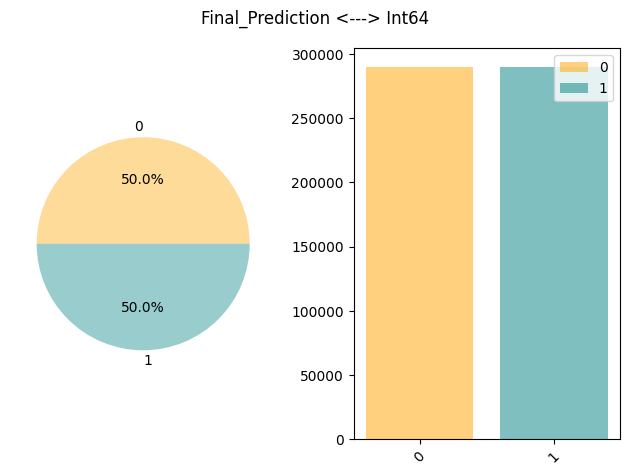

---------------Decision Tree---------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.92     78217
           1       0.98      0.89      0.93     95733

    accuracy                           0.93    173950
   macro avg       0.93      0.93      0.93    173950
weighted avg       0.93      0.93      0.93    173950




---------------Random Forest---------------
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     87569
           1       0.97      0.97      0.97     86381

    accuracy                           0.97    173950
   macro avg       0.97      0.97      0.97    173950
weighted avg       0.97      0.97      0.97    173950




---------------XG-Boost---------------
              precision    recall  f1-score   support

           0       0.60      0.62      0.61     84776
           1       0.62      0.61      0.62     89174

    accuracy                           0.61    17

In [46]:
dt_X, dt_y = sampler.stratified_eq_sampling(population_1.shape[0])
pipe.initialize(dt_X, dt_y, prep.normalize, 0.3)
vz.feature(dt_y)
pipe.process()